In [58]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Kode di atas mengimpor 3 library yang sering digunakan bersama untuk pengolahan gambar. Pertama, cv2 (OpenCV) bertugas membaca, menulis, dan memanipulasi gambar maupun video. Kedua, matplotlib.pyplot digunakan untuk menampilkan gambar dalam bentuk plot atau diagram. Ketiga, numpy berperan mengolah gambar sebagai array angka atau matriks piksel. Alur kerjanya sederhana, OpenCV membaca gambar, NumPy menyimpannya sebagai array, lalu Matplotlib menampilkannya ke layar.

In [59]:
def penyesuaian(citra, tinggi_baru, lebar_baru):
    tinggi_asal, lebar_asal = citra.shape[:2]  # :2 agar aman untuk grayscale maupun RGB
    skala_y = tinggi_asal / tinggi_baru
    skala_x = lebar_asal / lebar_baru

    # Cek apakah citra berwarna atau grayscale
    if len(citra.shape) == 3:
        hasil = np.zeros((tinggi_baru, lebar_baru, citra.shape[2]), dtype=np.uint8)
    else:
        hasil = np.zeros((tinggi_baru, lebar_baru), dtype=np.uint8)

    for i in range(tinggi_baru):
        for j in range(lebar_baru):
            y_asal = min(int(i * skala_y), tinggi_asal - 1)
            x_asal = min(int(j * skala_x), lebar_asal - 1)
            hasil[i, j] = citra[y_asal, x_asal]

    return hasil

## Fungsi Penyesuaian
Fungsi menerima input berupa gambar, tinggi baru, dan lebar baru, kemudian menghitung skala perubahan ukuran berdasarkan dimensi gambar asli. Program membuat array kosong sebagai wadah hasil resize, baik untuk gambar grayscale maupun RGB, lalu menggunakan perulangan untuk memetakan setiap piksel pada gambar baru ke piksel terdekat pada gambar asli menggunakan metode nearest neighbor interpolation. Setelah seluruh piksel diproses, hasil resize dikembalikan dalam bentuk array gambar baru.

### Menyiapkan dan Membaca citra yang akan di olah
Kode di bawah membaca 4 file gambar yaitu Meledak, Bunga, Langit, dan Windut dari folder Assets menggunakan fungsi plt.imread(), kemudian menyimpannya ke dalam variabel masing-masing dalam bentuk array piksel. Setelah itu, gambar Meledak ditampilkan ke layar menggunakan plt.imshow(), dan fungsi plt.show() digunakan untuk memunculkan hasil tampilan gambar tersebut.

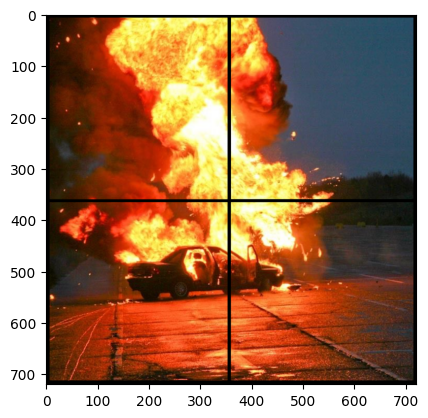

In [60]:
meledak = plt.imread('Assets/Meledak.png')
bunga = plt.imread('Assets/Bunga.png')
langit = plt.imread('Assets/Langit.png')
windut = plt.imread('Assets/Windut.png')

plt.imshow(meledak)
plt.show()

### Menampilkan citra Meledak yang telah di potong
Kode di bawah memotong gambar meledak menjadi 4 bagian menggunakan teknik slicing array NumPy, dimana setiap bagian disimpan ke dalam variabel mel1, mel2, mel3, dan mel4. Setelah itu, nilai piksel gambar diubah dari rentang desimal 0.0–1.0 menjadi 0–255 menggunakan operasi perkalian 255 dan konversi tipe data uint8 agar sesuai dengan format citra digital.

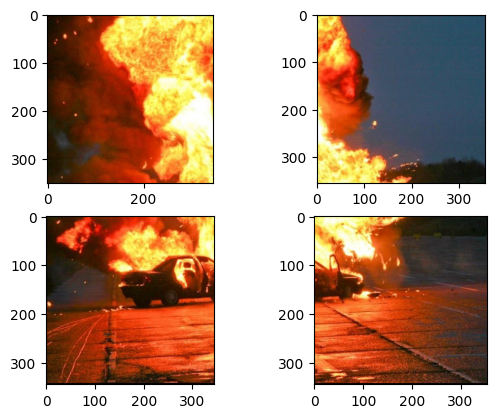

In [61]:
mel1 = meledak[5:355, 5:350]
mel2 = meledak[5:360, 360:715]
mel3 = meledak[370:715, 5:350]
mel4 = meledak[370:715, 360:715]

mel1 = (mel1 * 255).astype(np.uint8) 
mel2 = (mel2 * 255).astype(np.uint8)
mel3 = (mel3 * 255).astype(np.uint8)
mel4 = (mel4 * 255).astype(np.uint8)  # ubah 0.0-1.0 → 0-255

plt.subplot(2, 2, 1)
plt.imshow(mel1)

plt.subplot(2, 2, 2)
plt.imshow(mel2)

plt.subplot(2, 2, 3)
plt.imshow(mel3)

plt.subplot(2, 2, 4)
plt.imshow(mel4)


In [62]:
def ukuran_min(gambar):
    baris_min = min(len(citra) for citra in gambar)
    kolom_min = min(len(citra[0]) for citra in gambar)
    return baris_min, kolom_min

def potong(citra, tinggi, lebar):
    return [row[:lebar] for row in citra[:tinggi]]

def resize_semua(gambar):
    tinggi_min, lebar_min = ukuran_min(gambar)
    return [potong(citra, tinggi_min, lebar_min) for citra in gambar]

def ukuran_max(gambar):
    baris_max = max(len(citra) for citra in gambar)
    kolom_max = max(len(row) for citra in gambar for row in citra)
    return baris_max, kolom_max

def normalisasi(citra, baris_tujuan, kolom_tujuan):
    hasil = []
    for i in range(baris_tujuan):
        baris = []
        for j in range(kolom_tujuan):
            if i < len(citra) and j < len(citra[i]):
                baris.append(citra[i][j])
            else:
                baris.append(0)
        hasil.append(baris)
    return hasil

def gabung_2x2(citra1, citra2, citra3, citra4):
    citra1, citra2, citra3, citra4 = resize_semua([citra1, citra2, citra3, citra4])

    b, k = ukuran_max([citra1, citra2, citra3, citra4])
    i1 = normalisasi(citra1, b, k)
    i2 = normalisasi(citra2, b, k)
    i3 = normalisasi(citra3, b, k)
    i4 = normalisasi(citra4, b, k)

    gabung = []
    for i in range(b * 2):
        baris = []
        for j in range(k * 2):
            if i < b and j < k:
                baris.append(i1[i][j]) 
            elif i < b and j >= k:
                baris.append(i2[i][j - k]) 
            elif i >= b and j < k:
                baris.append(i3[i - b][j])
            else:
                baris.append(i4[i - b][j - k]) 
        gabung.append(baris)

    return gabung

## Fungsi Merge / Gabung
Fungsi ini menyamakan ukuran dan menggabungkan 4 citra menjadi satu tampilan grid 2x2. Fungsi ukuran_min() digunakan untuk mencari ukuran terkecil dari seluruh gambar, lalu potong() dan resize_semua() berfungsi memotong semua gambar agar memiliki ukuran yang sama. Setelah itu, fungsi ukuran_max() dan normalisasi() digunakan untuk menyesuaikan ukuran citra dengan menambahkan nilai 0 pada bagian yang kurang agar seluruh gambar memiliki dimensi seragam. Terakhir, fungsi gabung_2x2() menggabungkan keempat gambar ke dalam satu array besar dengan posisi kiri atas, kanan atas, kiri bawah, dan kanan bawah sehingga membentuk tampilan kolase 2x2.

### Menampilkan citra yang telah di gabung dengan fungsi Gabung/Merge yang telah dibuat sebelumnya
Kode di bawah digunakan untuk menggabungkan 4 potongan gambar yaitu mel1, mel2, mel3, dan mel4 menjadi satu tampilan grid 2x2 menggunakan fungsi gabung_2x2(), lalu hasil penggabungan tersebut disimpan ke dalam variabel gabung. Setelah itu, fungsi plt.imshow() digunakan untuk menampilkan hasil gambar gabungan tersebut ke layar.

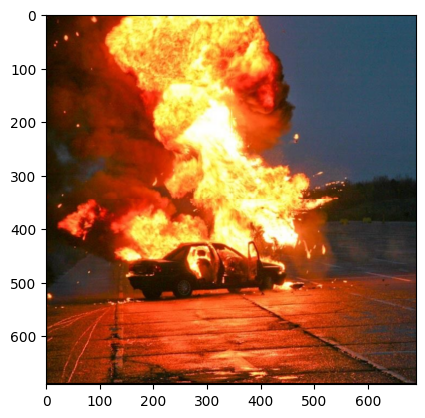

In [63]:
gabung = gabung_2x2(mel1, mel2, mel3, mel4)
plt.imshow(gabung)

### Menampilkan citra yang telah di lakukan grayscale
Kode di bawah mengubah variabel gabung menjadi array NumPy bertipe float32 menggunakan np.array() agar kompatibel dengan fungsi OpenCV. Setelah itu, fungsi cv.cvtColor() digunakan untuk mengubah gambar berwarna menjadi citra grayscale menggunakan mode cv.COLOR_BGR2GRAY.

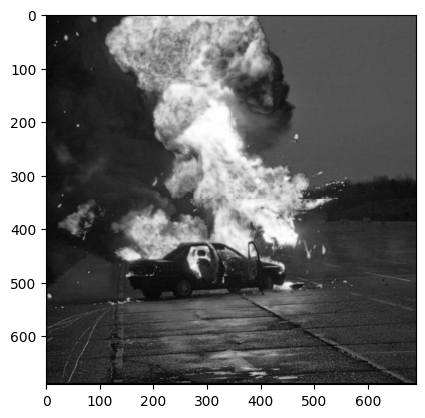

In [64]:
gabung = np.array(gabung, dtype=np.float32)  # ← tambahkan ini

mel_grey = cv.cvtColor(gabung, cv.COLOR_BGR2GRAY)
plt.imshow(mel_grey, cmap='gray')
plt.show()

In [65]:
# Fungsi untuk ekualisasi histogram
def ekualisasi_histogram(citra):
    panjang, lebar = citra.shape

    # Hitung histogram
    histogram = np.zeros(256, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            nilai = citra[i, j]
            histogram[nilai] += 1

    # Hitung CDF
    cdf = np.zeros(256, dtype=int)
    for i in range(256):
        cdf[i] = np.sum(histogram[:i+1])

    # Normalisasi CDF
    cdf_min = cdf[cdf > 0].min() if np.any(cdf > 0) else 0
    cdf_norm = np.round((cdf - cdf_min) / (panjang * lebar - cdf_min) * 255).astype(int)

    # Petakan nilai baru
    hasil = np.zeros_like(citra, dtype=int)
    for i in range(panjang):
        for j in range(lebar):
            val = citra[i, j]
            hasil[i, j] = cdf_norm[val]

    return hasil

## Fungsi Ekualisasi Histogram
Fungsi ekualisasi di atas merupakan fungsi manual untuk melakukan ekualisasi histogram pada citra grayscale guna meningkatkan kontras gambar. Proses dimulai dengan menghitung histogram citra, yaitu jumlah kemunculan setiap intensitas piksel dari 0–255 menggunakan perulangan. Setelah itu, program menghitung nilai CDF (Cumulative Distribution Function) untuk mengetahui distribusi kumulatif intensitas piksel. Nilai CDF kemudian dinormalisasi ke rentang 0–255 agar dapat digunakan sebagai pemetaan intensitas baru. Selanjutnya, setiap piksel pada citra asli diganti dengan nilai hasil normalisasi CDF sehingga distribusi intensitas menjadi lebih merata dan kontras gambar meningkat. Terakhir, citra hasil ekualisasi dikembalikan melalui return hasil.

### Menampilkan citra meledak sebelum diekualisasi dan setelah di ekualisasi dengan fungsi yang telah disiapkan sebelumnya
Kode di bawah digunakan untuk menerapkan ekualisasi histogram pada citra grayscale mel_grey. Pertama, citra diubah ke tipe data uint8 menggunakan astype() agar sesuai dengan proses pengolahan citra digital, lalu ukuran gambar disimpan ke dalam variabel panjang dan lebar. Setelah itu, fungsi ekualisasi_histogram() dipanggil untuk meningkatkan kontras gambar dan hasilnya disimpan pada variabel mel_eku.

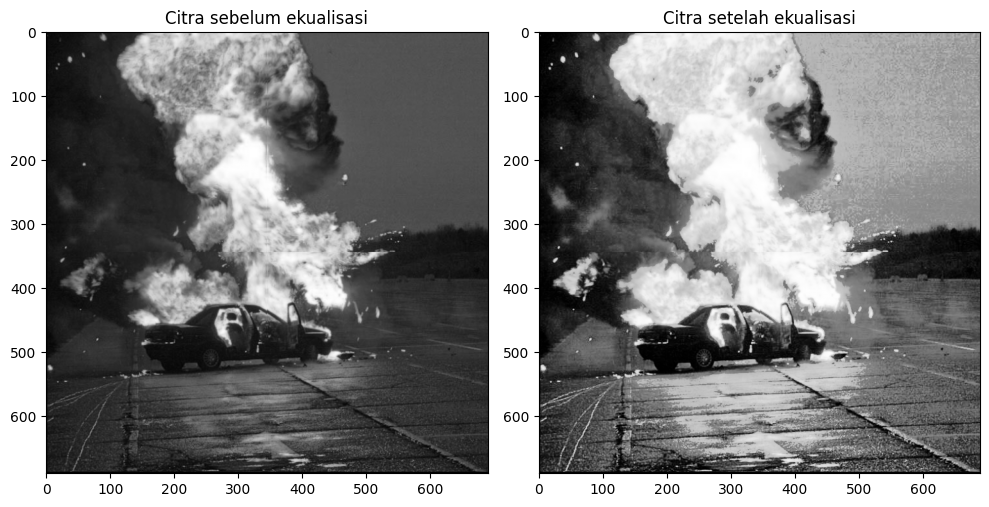

In [66]:
citra_gabung = (mel_grey).astype(np.uint8)

panjang, lebar = citra_gabung.shape
mel_eku = ekualisasi_histogram(citra_gabung)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(citra_gabung, cmap='gray')
plt.title("Citra sebelum ekualisasi")
plt.subplot(1, 2, 2)
plt.imshow(mel_eku, cmap='gray')
plt.title("Citra setelah ekualisasi")
plt.tight_layout()
plt.show()

In [67]:
def hitung_histogram(citra):
    import numpy as np
    
    if len(citra.shape) == 3:
        citra = np.mean(citra, axis=2)

    if citra.max() <= 1.0:
        citra = (citra * 255)

    citra = citra.astype('uint8')

    hist = np.bincount(citra.flatten(), minlength=256)
    return hist

## Fungsi Histogram
Fungsi di atas digunakan untuk menghitung histogram citra, yaitu jumlah kemunculan setiap intensitas piksel dari 0–255. Pertama, program mengecek apakah gambar memiliki 3 channel warna (RGB), lalu mengubahnya menjadi grayscale menggunakan rata-rata nilai channel dengan np.mean(). Setelah itu, jika nilai piksel masih berada pada rentang 0.0–1.0, program mengubahnya menjadi 0–255 dengan mengalikan 255. Citra kemudian dikonversi ke tipe data uint8 agar sesuai dengan format intensitas standar. Terakhir, fungsi np.bincount() digunakan untuk menghitung frekuensi setiap nilai intensitas piksel dan hasil histogram dikembalikan melalui return hist.

### Menampilkan hsitogram citra sebelum dan sesudah ekualisasi dengan fungsi yang telah di siapkan sebelumnya
Kode di bawah digunakan untuk menghitung dan menampilkan histogram perbandingan antara citra sebelum dan sesudah ekualisasi histogram. Pertama, fungsi hitung_histogram() dipanggil untuk menghitung distribusi intensitas piksel pada citra_gabung dan mel_eku, lalu hasilnya disimpan pada variabel histo dan histoEku. Setelah itu, program membuat area tampilan menggunakan plt.figure() dan menampilkan kedua histogram dengan plt.bar(), dimana histogram sebelum ekualisasi ditampilkan berwarna biru dan histogram setelah ekualisasi berwarna kuning.

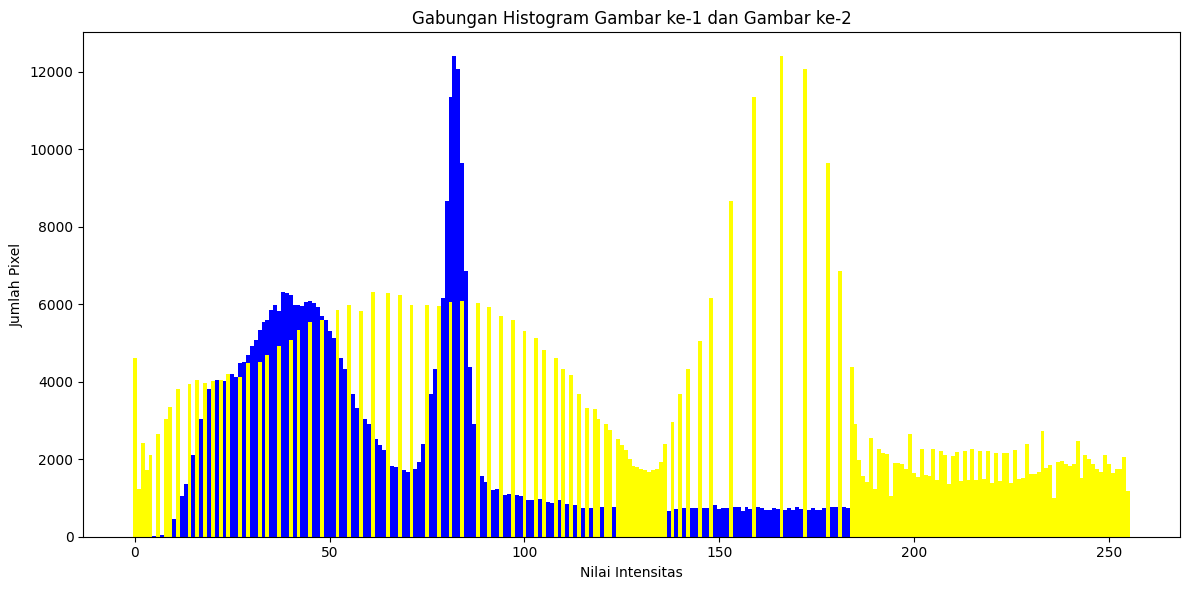

In [68]:
histo = hitung_histogram(citra_gabung) # sebelum di ekualisasi
histoEku = hitung_histogram(mel_eku) # setelah di ekualisasi

plt.figure(figsize=(12, 6))

plt.bar(range(256), histo, width=1, color='blue') # sebelum di ekualisasi

plt.bar(range(256), histoEku, width=1, color='yellow') # setelah di ekualisasi

plt.title('Gabungan Histogram Gambar ke-1 dan Gambar ke-2')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [69]:
def spesifikasi_histogram(citra_sumber, citra_target):
    # Pastikan tipe data uint8
    citra_sumber = np.array(citra_sumber, dtype=np.uint8)
    citra_target = np.array(citra_target, dtype=np.uint8)
    
    panjang_sumber, lebar_sumber = citra_sumber.shape
    panjang_target, lebar_target = citra_target.shape

    # Hitung histogram
    histogram_sumber = np.zeros(256, dtype=np.int32)
    histogram_target = np.zeros(256, dtype=np.int32)
    
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            histogram_sumber[citra_sumber[i, j]] += 1
            
    for i in range(panjang_target):
        for j in range(lebar_target):
            histogram_target[citra_target[i, j]] += 1

    # Hitung CDF
    cdf_sumber = np.cumsum(histogram_sumber)
    cdf_target = np.cumsum(histogram_target)

    # Normalisasi CDF (skala 0-1)
    cdf_sumber_norm = cdf_sumber / cdf_sumber[-1] if cdf_sumber[-1] != 0 else cdf_sumber
    cdf_target_norm = cdf_target / cdf_target[-1] if cdf_target[-1] != 0 else cdf_target

    # Buat lookup table (pemetaan)
    pemetaan = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        # Cari indeks di target yang paling mendekati
        idx = np.argmin(np.abs(cdf_target_norm - cdf_sumber_norm[i]))
        pemetaan[i] = idx

    # Terapkan pemetaan
    hasil = np.zeros_like(citra_sumber)
    for i in range(panjang_sumber):
        for j in range(lebar_sumber):
            hasil[i, j] = pemetaan[citra_sumber[i, j]]

    return hasil

## Fungsi Spesifikasi Histogram
Fungsi di atas merupakan fungsi manual untuk melakukan spesifikasi histogram (histogram matching), yaitu proses menyesuaikan distribusi intensitas citra sumber agar menyerupai citra target. Pertama, kedua citra dikonversi ke tipe data uint8, lalu program menghitung histogram masing-masing citra menggunakan perulangan untuk mengetahui jumlah setiap intensitas piksel. Setelah itu, nilai CDF (Cumulative Distribution Function) dari histogram sumber dan target dihitung menggunakan np.cumsum(), kemudian dinormalisasi ke rentang 0–1. Selanjutnya, program membuat lookup table atau tabel pemetaan dengan mencari intensitas pada citra target yang memiliki nilai CDF paling mendekati intensitas pada citra sumber menggunakan np.argmin(). Terakhir, pemetaan tersebut diterapkan ke seluruh piksel citra sumber sehingga distribusi histogram hasil menjadi mirip dengan histogram citra target, lalu hasil akhir dikembalikan melalui return hasil.

### Menampilkan citra windut dan bunga dengan menerapkan greyscale
Kode di bawah digunakan untuk mengubah gambar windut dan bunga dari citra berwarna menjadi citra grayscale menggunakan fungsi cv.cvtColor() dengan mode cv.COLOR_BGR2GRAY. Hasil konversi kemudian disimpan pada variabel windut_grey dan bunga_grey

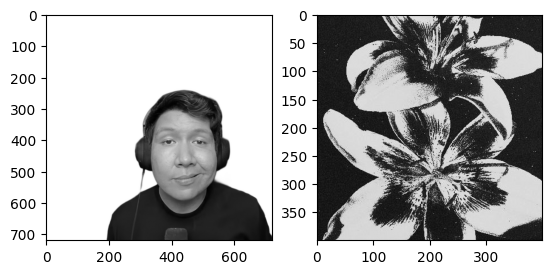

In [70]:
windut_grey = cv.cvtColor(windut, cv.COLOR_BGR2GRAY)
bunga_grey = cv.cvtColor(bunga, cv.COLOR_BGR2GRAY)

plt.subplot(1, 2, 1)
plt.imshow(windut_grey, cmap ='gray')
plt.subplot(1, 2, 2)
plt.imshow(bunga_grey, cmap ='gray')

### Menampilkan citra windut yang di spesifikasi dengan bunga
Kode di bawah digunakan untuk melakukan spesifikasi histogram pada citra windut_grey dengan menjadikan bunga_grey sebagai citra target. Pertama, kedua citra grayscale diubah dari rentang nilai 0.0–1.0 menjadi 0–255 dan dikonversi ke tipe data uint8 agar sesuai dengan format citra digital. Setelah itu, fungsi spesifikasi_histogram() dipanggil untuk menyesuaikan distribusi intensitas piksel citra windut_grey agar menyerupai histogram dari bunga_grey, lalu hasilnya disimpan pada variabel windut_sp.

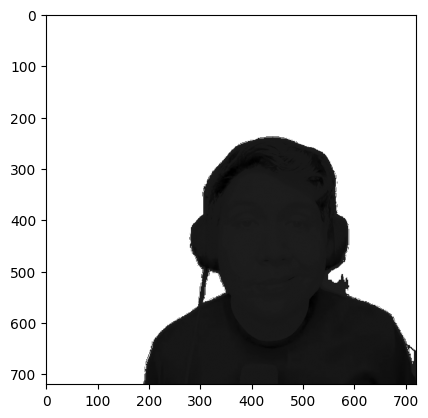

In [71]:
windut_grey = (windut_grey * 255).astype(np.uint8)
bunga_grey = (bunga_grey * 255).astype(np.uint8)

windut_sp = spesifikasi_histogram (windut_grey, bunga_grey)

plt.imshow(windut_sp, cmap = 'gray')

### Menampilkan histogram windut yang di spesifikasi
Kode di bawah digunakan untuk menghitung dan menampilkan histogram dari citra windut_sp yang telah melalui proses spesifikasi histogram. Pertama, fungsi hitung_histogram() dipanggil untuk menghitung distribusi intensitas piksel pada citra hasil spesifikasi, lalu hasilnya disimpan pada variabel histoWindut. Setelah itu, program membuat area tampilan menggunakan plt.figure() dan menampilkan histogram menggunakan plt.bar() dengan warna merah.

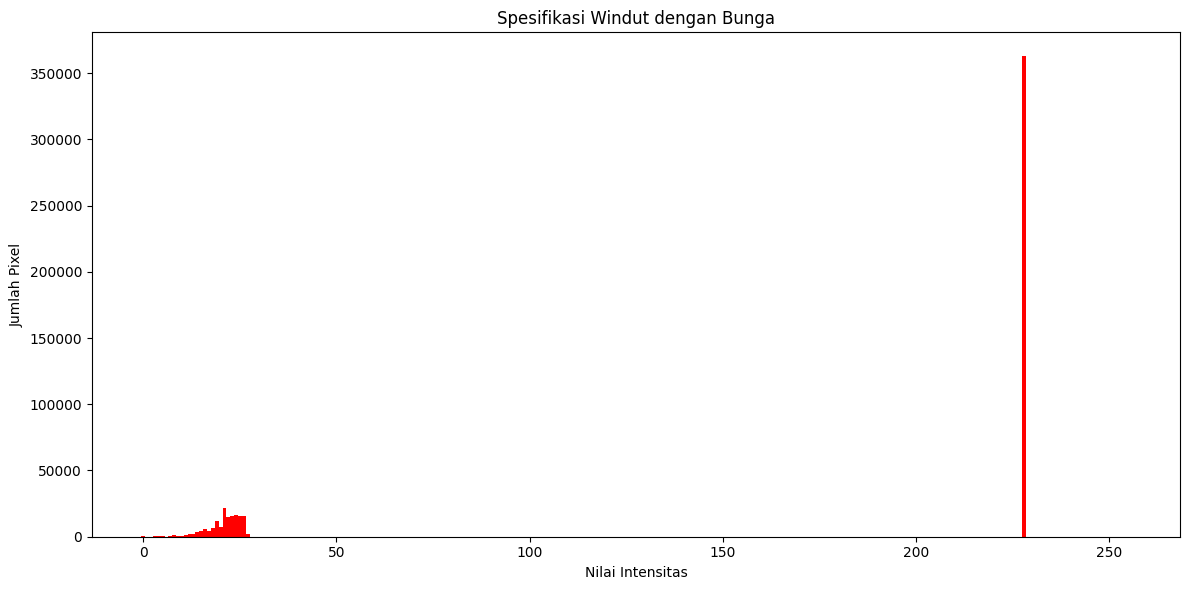

In [72]:
histoWindut = hitung_histogram(windut_sp) 

plt.figure(figsize=(12, 6))

plt.bar(range(256), histoWindut, width=1, color='red') 

plt.title('Spesifikasi Windut dengan Bunga')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [73]:
def copy_citra(citra):
    h, w = citra.shape
    hasil = np.zeros((h, w), dtype=citra.dtype)

    for i in range(h):
        for j in range(w):
            hasil[i][j] = citra[i][j]

    return hasil

## Fungsi Copy Citra
Fungsi copy_citra untuk menduplikasi gambar secara manual tanpa menggunakan fungsi bawaan seperti np.copy. Fungsi membuat kanvas kosong berukuran sama dengan gambar asli menggunakan np.zeros, lalu menyalin nilai setiap piksel satu per satu melalui dua perulangan for. Hasilnya adalah gambar baru yang identik dengan aslinya namun tersimpan di lokasi memori yang berbeda, sehingga perubahan pada hasil salinan tidak akan mempengaruhi gambar aslinya.

In [74]:
def tumpuk(citra_depan, citra_belakang):
    hasil = copy_citra(citra_depan)

    for i in range(citra_depan.shape[0]):
        for j in range(citra_depan.shape[1]):
            if citra_depan[i, j] > 50:   # area putih → tampilkan ledakan
                hasil[i, j] = citra_belakang[i, j]
            else:                         # area hitam → tetap hitam
                hasil[i, j] = 0

    return hasil

## Fungsi Tumpuk Gambar
Fungsi tumpuk untuk menggabungkan dua gambar dengan cara menumpuk citra_atas di atas citra_bawah. Pertama, gambar bawah disalin menggunakan fungsi copy_citra agar gambar aslinya tidak berubah. Kemudian dicek apakah citra_atas merupakan gambar grayscale (2 dimensi) menggunakan len(citra_atas.shape) == 2, lalu dibuat mask yang menandai piksel-piksel pada citra_atas yang nilainya bukan 0 (bukan hitam). Hanya piksel yang termasuk dalam mask tersebut yang akan ditumpukkan ke gambar bawah, sehingga bagian hitam pada citra_atas dianggap transparan dan tidak menutupi gambar bawah.

### Menampilkan citra siluet windut dengan background meledak grayscale
Kode di bawah digunakan untuk mengubah ukuran citra mel_eku menjadi 720x720 menggunakan fungsi penyesuaian() agar ukurannya sesuai dengan citra lain yang akan digabungkan. Setelah itu, fungsi tumpuk() digunakan untuk menumpuk citra windut_sp di atas mel_eku, sehingga kedua gambar dapat digabungkan menjadi satu tampilan. Terakhir, hasil penggabungan tersebut disimpan pada variabel windah_mel

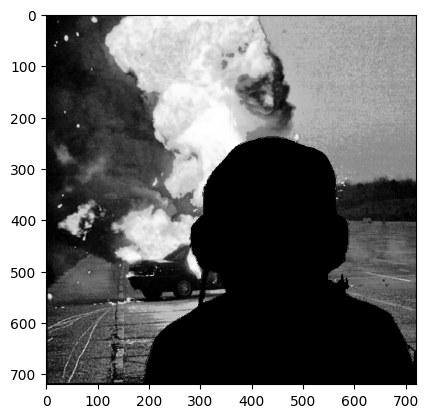

In [75]:
mel_eku = penyesuaian(mel_eku, 720, 720)

windah_mel = tumpuk(windut_sp, mel_eku)

plt.imshow(windah_mel, cmap='gray')


In [76]:
def tumpuk_depan(citra_hitam, citra_asli, citra_belakang):
    hasil = copy_citra(citra_belakang)

    for i in range(citra_hitam.shape[0]):
        for j in range(citra_hitam.shape[1]):
            if citra_hitam[i, j] < 50:   # area hitam → pakai foto asli
                hasil[i, j] = citra_asli[i, j]

    return hasil

## Fungsi Tumpuk Depan
Fungsi tumpuk_depan() digunakan untuk menggabungkan dua gambar dengan memanfaatkan citra hitam sebagai penanda area transparan. Pertama, gambar belakang disalin ke variabel hasil menggunakan fungsi copy_citra() agar gambar asli tidak berubah. Kemudian program melakukan perulangan untuk memeriksa setiap piksel pada citra_hitam. Jika nilai piksel kurang dari 50, yang dianggap sebagai area hitam, maka piksel pada posisi tersebut akan diganti menggunakan piksel dari citra_asli. Dengan cara ini, bagian hitam pada citra_hitam akan menampilkan gambar asli di atas gambar belakang sehingga menghasilkan efek penumpukan gambar

### Menampilkan citra yang sebelumnya siluet windut menjadi windut asli dengan grayscale
Kode di bawah digunakan untuk menggabungkan citra windut_grey dengan mel_eku menggunakan fungsi tumpuk_depan(), dimana citra windut_sp berperan sebagai penanda area hitam yang akan diganti menggunakan gambar asli. Hasil penggabungan tersebut disimpan pada variabel windah_mel2

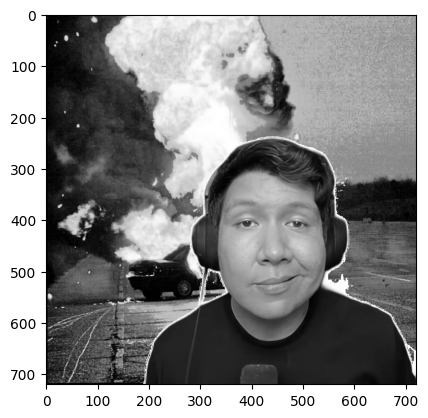

In [77]:
windah_mel2 = tumpuk_depan(windut_sp, windut_grey, mel_eku)

plt.imshow(windah_mel2, cmap='gray')
plt.show()

### Menampilkan citra langit dengan grayscale
Kode di bawah digunakan untuk mengubah gambar langit dari citra berwarna menjadi citra grayscale menggunakan fungsi cv.cvtColor() dengan mode cv.COLOR_BGR2GRAY. Setelah itu, nilai piksel citra diubah dari rentang 0.0–1.0 menjadi 0–255 dan dikonversi ke tipe data uint8 agar sesuai dengan format citra digital

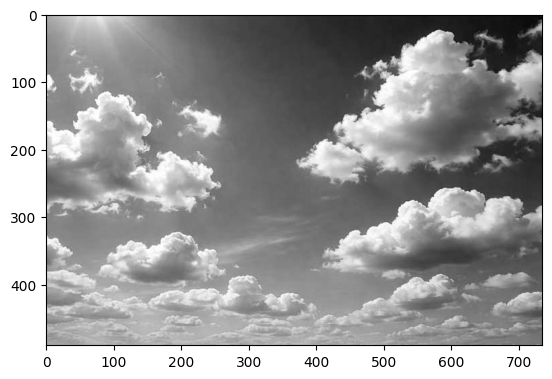

In [78]:
langit_gray = cv.cvtColor(langit, cv.COLOR_BGR2GRAY)
langit_gray = (langit_gray * 255).astype(np.uint8)

plt.imshow(langit_gray, cmap = 'gray')

### Menampilkan citra windut meledak dengan menerapkan spesfikasi terhdapat citra langit
Kode di bawah digunakan untuk melakukan spesifikasi histogram pada citra windah_mel2 dengan menjadikan langit_gray sebagai citra target. Fungsi spesifikasi_histogram() akan menyesuaikan distribusi intensitas piksel pada windah_mel2 agar menyerupai histogram dari langit_gray, sehingga karakter pencahayaan dan kontras gambar menjadi lebih mirip dengan citra target. Hasil proses tersebut disimpan pada variabel windut_langit

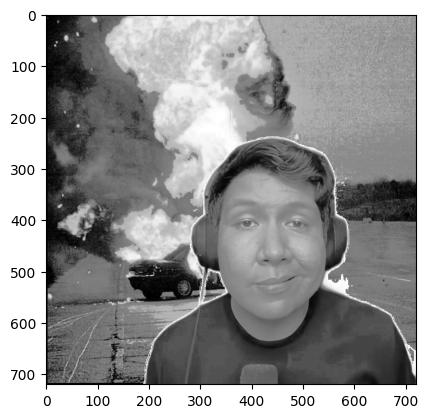

In [79]:
windut_langit = spesifikasi_histogram (windah_mel2, langit_gray)
plt.imshow(windut_langit, cmap = 'gray')

### Menampilkan histogram hasil spesifikasi dengan langit
Kode di bawah digunakan untuk menghitung dan menampilkan histogram dari citra windut_langit yang telah melalui proses spesifikasi histogram. Pertama, fungsi hitung_histogram() dipanggil untuk menghitung distribusi intensitas piksel pada citra hasil spesifikasi, lalu hasilnya disimpan pada variabel histoLangit. Setelah itu, program membuat area tampilan menggunakan plt.figure() dan menampilkan histogram menggunakan plt.bar() dengan warna merah

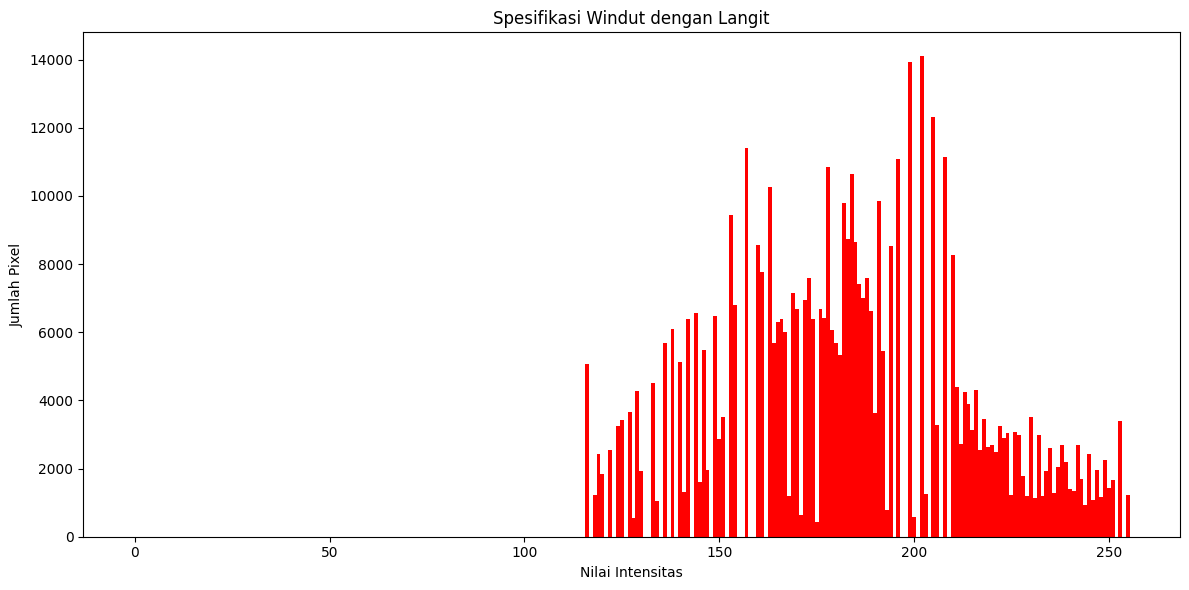

In [80]:
histoLangit = hitung_histogram(windut_langit)

plt.figure(figsize=(12, 6))

plt.bar(range(256), histoLangit, width=1, color='red')

plt.title('Spesifikasi Windut dengan Langit')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

### Menyiapkan ulang citra untuk proses citra berwarna
Kode di bawah digunakan untuk menyiapkan dua citra berwarna yang akan digunakan pada proses selanjutnya. Pertama, gambar Windut.png dibaca menggunakan cv.imread() dan disimpan pada variabel windah_color. Kemudian, variabel gabung diubah dari format warna BGR menjadi RGB menggunakan cv.cvtColor() dengan mode cv.COLOR_BGR2RGB, lalu disimpan pada variabel meledak_color. Setelah itu, kedua gambar diubah ukurannya menjadi 720x720 menggunakan fungsi resize() agar memiliki dimensi yang sama sehingga lebih mudah untuk diproses atau digabungkan

In [81]:
windah_color = cv.imread('Assets/Windut.png')

meledak_color = cv.cvtColor(gabung, cv.COLOR_BGR2RGB)

windah_color  = penyesuaian(windah_color, 720, 720)
meledak_color = penyesuaian(meledak_color, 720, 720)

In [82]:
def tumpuk_color(citra_hitam, citra_asli_color, citra_belakang_color):
    hasil = np.zeros((citra_belakang_color.shape[0], 
                      citra_belakang_color.shape[1], 3), dtype=np.uint8)

    for i in range(citra_hitam.shape[0]):
        for j in range(citra_hitam.shape[1]):
            if citra_hitam[i, j] < 50:   # area hitam → wajah berwarna
                hasil[i, j] = citra_asli_color[i, j]
            else:                         # area putih → ledakan berwarna
                hasil[i, j] = citra_belakang_color[i, j]

    return hasil

## Fungsi Tumpuk Color
Fungsi tumpuk_color() digunakan untuk menggabungkan dua citra berwarna dengan memanfaatkan citra hitam sebagai penanda area transparan. Pertama, program membuat array kosong bernama hasil dengan 3 channel warna RGB menggunakan np.zeros() sebagai wadah hasil penggabungan gambar. Kemudian dilakukan perulangan untuk memeriksa setiap piksel pada citra_hitam. Jika nilai piksel kurang dari 50, yang dianggap sebagai area hitam, maka piksel pada posisi tersebut akan diisi menggunakan piksel dari citra_asli_color. Sebaliknya, jika bukan area hitam, maka piksel akan diambil dari citra_belakang_color. Dengan cara ini, bagian hitam akan menampilkan gambar asli berwarna, sedangkan bagian lainnya menampilkan gambar latar belakang berwarna.

### Menampilkan citra windut hasil proses tumpuk gambar berwarna
Kode di bawah digunakan untuk menggabungkan citra windah_color dengan meledak_color menggunakan fungsi tumpuk_color(), dimana citra windut_sp digunakan sebagai penanda area hitam untuk menentukan bagian gambar yang akan ditampilkan. Hasil penggabungan tersebut disimpan pada variabel windah_mel_color

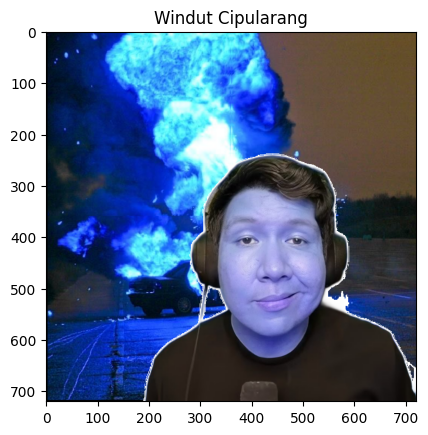

In [83]:
windah_mel_color = tumpuk_color(windut_sp, windah_color, meledak_color)

plt.imshow(windah_mel_color)   # tanpa cmap='gray' karena sudah RGB
plt.title("Windut Cipularang")
plt.show()

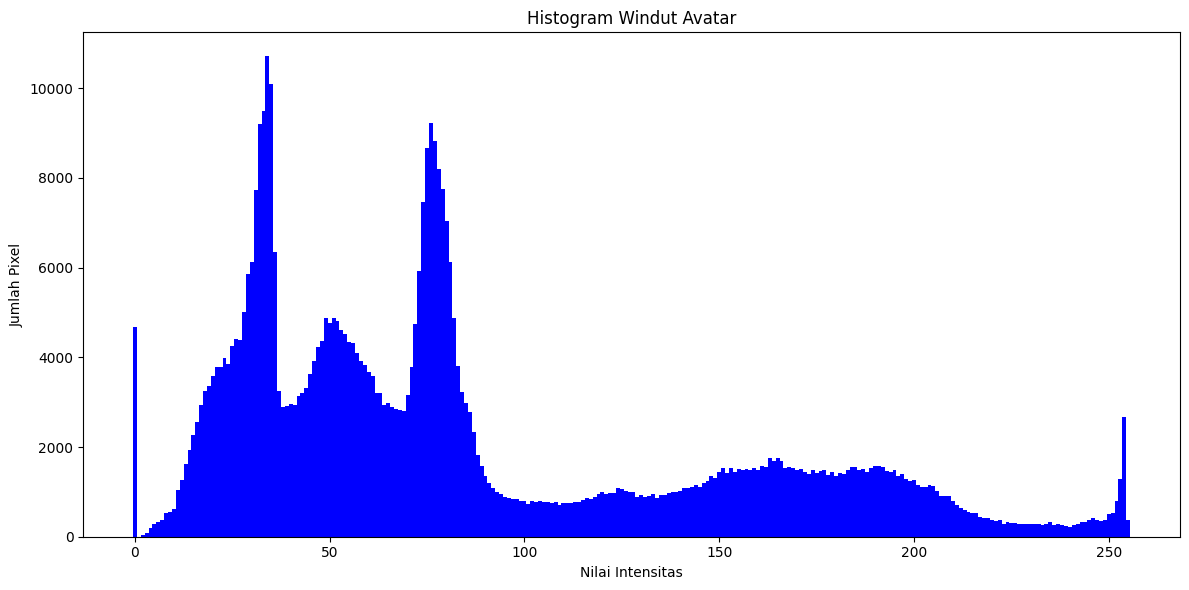

In [84]:
histo_biru = hitung_histogram(windah_mel_color)
plt.figure(figsize=(12, 6))

plt.bar(range(256), histo_biru, width=1, color='blue') 
plt.title('Histogram Windut Avatar')
plt.xlabel('Nilai Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()